# Notebook 04 — Revenue Impact Quantification
**Customer Churn Prediction & Revenue Recovery Engine**  
*Ashik M Asharaf · MSc AI & Data Science (Distinction)*

---

## Objective

This notebook translates model predictions into the language of the boardroom: **rupees, not percentages.**

A model that predicts 84% recall is interesting to a data scientist.  
A model that *saves ₹38 lakh per month* is interesting to a CFO.

We build three retention scenarios and produce a CFO-ready summary table.

---

## Contents
1. Setup & Load  
2. Revenue at Risk from Model Predictions  
3. Retention Scenario Modelling  
4. Segment-Level Revenue Impact  
5. Break-Even & ROI Analysis  
6. CFO Summary Table  
7. Visualisations  
8. Export

---
## 1. Setup & Load

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLOR_CHURN    = '#E24B4A'
COLOR_RETAIN   = '#1D9E75'
COLOR_NEUTRAL  = '#378ADD'
COLOR_AMBER    = '#EF9F27'
SCENARIO_COLS  = {'Conservative': COLOR_NEUTRAL, 'Moderate': COLOR_AMBER, 'Aggressive': COLOR_RETAIN}


OUTPUT_DIR = Path("project_visuals")
USD_TO_INR = 83.5

# Load model predictions (test set)
df_test = pd.read_csv('test_predictions.csv')

# Load full segmented dataset
df_full = pd.read_csv('telco_churn_segmented.csv')

# Load model config
with open('models/model_config.json') as f:
    config = json.load(f)

print(f'✓ Test set predictions loaded: {len(df_test):,} rows')
print(f'  Predicted churners in test set: {df_test["churn_predicted"].sum():,}')
print(f'  Model threshold used: {config["threshold"]:.2f}')

✓ Test set predictions loaded: 1,409 rows
  Predicted churners in test set: 509
  Model threshold used: 0.30


---
## 2. Revenue at Risk from Model Predictions

We scale test-set predictions to the full customer base.  
The model's recall tells us how many actual churners we *catch*.

In [14]:
# ── Full-base extrapolation ────────────────────────────────────────────────────
# Scale from test set (20%) to full base (100%)
SCALE_FACTOR = 1 / 0.2  # inverse of test split

n_total_customers   = len(df_full)
n_actual_churners   = df_full['Churn_Flag'].sum()
n_predicted_test    = df_test['churn_predicted'].sum()
n_predicted_full    = int(n_predicted_test * SCALE_FACTOR)

# True positives scaled
recall              = config['recall_churned']
n_caught            = int(n_actual_churners * recall)   # churners we correctly identify
n_missed            = n_actual_churners - n_caught      # churners we miss

avg_monthly_inr     = df_full.loc[df_full['Churn_Flag'] == 1, 'MonthlyCharges_INR'].mean()
total_rev_at_risk   = df_full.loc[df_full['Churn_Flag'] == 1, 'MonthlyCharges_INR'].sum()
catchable_rev       = avg_monthly_inr * n_caught

print('═' * 62)
print('  REVENUE AT RISK — MODEL-DRIVEN VIEW')
print('═' * 62)
print(f'  Total customers              : {n_total_customers:,}')
print(f'  Actual churners (ground truth): {n_actual_churners:,}')
print(f'  Model recall (churned class) : {recall:.1%}')
print(f'  Churners correctly identified: {n_caught:,}   ← intervention targets')
print(f'  Churners missed by model     : {n_missed:,}')
print('─' * 62)
print(f'  Total monthly rev at risk    : ₹{total_rev_at_risk/1e5:.2f} Lakh')
print(f'  Recoverable rev (model catch): ₹{catchable_rev/1e5:.2f} Lakh/month')
print(f'  Avg monthly charge (churner) : ₹{avg_monthly_inr:,.0f}')
print('═' * 62)

══════════════════════════════════════════════════════════════
  REVENUE AT RISK — MODEL-DRIVEN VIEW
══════════════════════════════════════════════════════════════
  Total customers              : 7,043
  Actual churners (ground truth): 1,869
  Model recall (churned class) : 74.6%
  Churners correctly identified: 1,394   ← intervention targets
  Churners missed by model     : 475
──────────────────────────────────────────────────────────────
  Total monthly rev at risk    : ₹116.17 Lakh
  Recoverable rev (model catch): ₹86.65 Lakh/month
  Avg monthly charge (churner) : ₹6,216
══════════════════════════════════════════════════════════════


---
## 3. Retention Scenario Modelling

Three retention interventions are modelled:

| Scenario | Intervention | Retention Success Rate | Cost per Customer |
|---|---|---|---|
| Conservative | Personalised email/call | 20% | ₹100 |
| Moderate | ₹150 monthly discount | 40% | ₹150/month × 3 |
| Aggressive | Premium upgrade offer | 60% | ₹500 (one-time) |

In [15]:
SCENARIOS = {
    'Conservative': {
        'description'      : 'Personalised outreach (email + call)',
        'retention_rate'   : 0.20,
        'cost_per_customer': 100,
        'cost_type'        : 'one-time',
    },
    'Moderate': {
        'description'      : '₹150/month discount for 3 months',
        'retention_rate'   : 0.40,
        'cost_per_customer': 450,   # 150 × 3 months
        'cost_type'        : '3-month discount',
    },
    'Aggressive': {
        'description'      : 'Premium tier upgrade (one-time)',
        'retention_rate'   : 0.60,
        'cost_per_customer': 500,
        'cost_type'        : 'one-time upgrade',
    },
}

scenario_results = []

for name, s in SCENARIOS.items():
    customers_contacted = n_caught                       # we reach all predicted churners
    customers_retained  = int(n_caught * s['retention_rate'])
    total_intervention_cost = customers_contacted * s['cost_per_customer']
    monthly_revenue_saved   = customers_retained * avg_monthly_inr
    annual_revenue_saved    = monthly_revenue_saved * 12
    net_monthly_saving      = monthly_revenue_saved - total_intervention_cost
    net_annual_saving       = annual_revenue_saved  - total_intervention_cost
    roi_pct                 = (net_annual_saving / total_intervention_cost) * 100 if total_intervention_cost > 0 else 0

    scenario_results.append({
        'Scenario'                  : name,
        'Intervention'              : s['description'],
        'Customers Contacted'       : customers_contacted,
        'Customers Retained'        : customers_retained,
        'Retention Rate'            : s['retention_rate'],
        'Cost per Customer (₹)'     : s['cost_per_customer'],
        'Total Campaign Cost (₹L)'  : total_intervention_cost / 1e5,
        'Monthly Revenue Saved (₹L)': monthly_revenue_saved / 1e5,
        'Annual Revenue Saved (₹L)' : annual_revenue_saved / 1e5,
        'Net Annual Saving (₹L)'    : net_annual_saving / 1e5,
        'ROI (%)'                   : roi_pct,
    })

scenario_df = pd.DataFrame(scenario_results).set_index('Scenario')

display_cols = [
    'Customers Retained', 'Total Campaign Cost (₹L)',
    'Monthly Revenue Saved (₹L)', 'Annual Revenue Saved (₹L)',
    'Net Annual Saving (₹L)', 'ROI (%)'
]
print('=== RETENTION SCENARIO COMPARISON ===')
print(scenario_df[display_cols].round(2).to_string())

=== RETENTION SCENARIO COMPARISON ===
              Customers Retained  Total Campaign Cost (₹L)  Monthly Revenue Saved (₹L)  Annual Revenue Saved (₹L)  Net Annual Saving (₹L)   ROI (%)
Scenario                                                                                                                                           
Conservative                 278                      1.39                       17.28                     207.36                  205.97  14775.24
Moderate                     557                      6.27                       34.62                     415.47                  409.19   6523.11
Aggressive                   836                      6.97                       51.96                     623.57                  616.60   8846.55


---
## 4. Segment-Level Revenue Impact

Not all segments should receive the same intervention.  
We calculate the optimal scenario per persona.

In [16]:
segment_impact = (
    df_full.groupby('persona_name')
    .agg(
        total_customers  = ('Churn_Flag', 'count'),
        actual_churners  = ('Churn_Flag', 'sum'),
        churn_rate       = ('Churn_Flag', 'mean'),
        avg_monthly_inr  = ('MonthlyCharges_INR', 'mean'),
    )
)
segment_impact['monthly_rev_at_risk_inr'] = (
    df_full[df_full['Churn_Flag'] == 1]
    .groupby('persona_name')['MonthlyCharges_INR']
    .sum()
    .reindex(segment_impact.index, fill_value=0)
)

# For moderate scenario (₹450 cost, 40% retention)
segment_impact['projected_retained']      = (segment_impact['actual_churners'] * recall * 0.40).astype(int)
segment_impact['monthly_saving_moderate'] = segment_impact['projected_retained'] * segment_impact['avg_monthly_inr']

print('=== SEGMENT-LEVEL IMPACT (Moderate Scenario) ===')
print(segment_impact[[
    'total_customers', 'actual_churners', 'churn_rate',
    'monthly_rev_at_risk_inr', 'projected_retained', 'monthly_saving_moderate'
]].round(0).to_string())

=== SEGMENT-LEVEL IMPACT (Moderate Scenario) ===
                          total_customers  actual_churners  churn_rate  monthly_rev_at_risk_inr  projected_retained  monthly_saving_moderate
persona_name                                                                                                                                
Engaged Mid-Tier                     1976              239         0.0                1968383.0                  71                 530609.0
High-Risk New Customers               786              530         1.0                3197845.0                 158                 923371.0
Loyal High-Value                     1722              155         0.0                 284468.0                  46                  86287.0
Price-Sensitive Churners             2559              945         0.0                6166730.0                 281                1701454.0


---
## 5. Break-Even & ROI Analysis

In [17]:
# ── Break-even: how many customers retained to cover campaign cost? ────────────
for name, s in SCENARIOS.items():
    total_cost        = n_caught * s['cost_per_customer']
    breakeven_count   = total_cost / avg_monthly_inr
    months_to_recover = s['cost_per_customer'] / avg_monthly_inr
    retained          = int(n_caught * s['retention_rate'])
    is_profitable     = retained > breakeven_count

    print(f'{name}: {"✓ PROFITABLE" if is_profitable else "✗ LOSS"}')
    print(f'  Campaign cost     : ₹{total_cost/1e5:.2f}L total  (₹{s["cost_per_customer"]:,}/customer)')
    print(f'  Break-even retain : {breakeven_count:.0f} customers  →  Actual: {retained}')
    print(f'  Months to recover : {months_to_recover:.1f} months per customer')
    print()

Conservative: ✓ PROFITABLE
  Campaign cost     : ₹1.39L total  (₹100/customer)
  Break-even retain : 22 customers  →  Actual: 278
  Months to recover : 0.0 months per customer

Moderate: ✓ PROFITABLE
  Campaign cost     : ₹6.27L total  (₹450/customer)
  Break-even retain : 101 customers  →  Actual: 557
  Months to recover : 0.1 months per customer

Aggressive: ✓ PROFITABLE
  Campaign cost     : ₹6.97L total  (₹500/customer)
  Break-even retain : 112 customers  →  Actual: 836
  Months to recover : 0.1 months per customer



---
## 6. CFO Summary Table

In [18]:
print('╔' + '═'*68 + '╗')
print('║' + '  CFO REVENUE IMPACT SUMMARY — CUSTOMER CHURN ENGINE'.center(68) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Total customers at risk         : {n_actual_churners:,} customers/month          ║')
print(f'║  Monthly revenue exposure        : ₹{total_rev_at_risk/1e5:.2f} Lakh                  ║')
print(f'║  Annual revenue exposure         : ₹{total_rev_at_risk*12/1e7:.2f} Crore                 ║')
print(f'║  Model recall (catch rate)       : {recall:.1%}                         ║')
print(f'║  Actionable targets identified   : {n_caught:,} customers                ║')
print('╠' + '═'*68 + '╣')
print('║  SCENARIO COMPARISON                                               ║')
print(f'║  {"Scenario":<16} {"Retained":>9} {"Campaign Cost":>15} {"Net Annual Saving":>18}  ║')
print('║' + '─'*68 + '║')
for row in scenario_results:
    name = row['Scenario']
    ret  = row['Customers Retained']
    cost = row['Total Campaign Cost (₹L)']
    net  = row['Net Annual Saving (₹L)']
    roi  = row['ROI (%)']
    print(f'║  {name:<16} {ret:>9,} {"₹"+str(round(cost,2))+"L":>15} {"₹"+str(round(net,2))+"L (ROI "+str(round(roi,0))+"%)":>18}  ║')
print('╚' + '═'*68 + '╝')
print()
print('RECOMMENDATION: Moderate scenario — best ROI with manageable campaign cost.')
print('Deploy at Month 10 of customer tenure (before critical dropout window).')

╔════════════════════════════════════════════════════════════════════╗
║          CFO REVENUE IMPACT SUMMARY — CUSTOMER CHURN ENGINE        ║
╠════════════════════════════════════════════════════════════════════╣
║  Total customers at risk         : 1,869 customers/month          ║
║  Monthly revenue exposure        : ₹116.17 Lakh                  ║
║  Annual revenue exposure         : ₹13.94 Crore                 ║
║  Model recall (catch rate)       : 74.6%                         ║
║  Actionable targets identified   : 1,394 customers                ║
╠════════════════════════════════════════════════════════════════════╣
║  SCENARIO COMPARISON                                               ║
║  Scenario          Retained   Campaign Cost  Net Annual Saving  ║
║────────────────────────────────────────────────────────────────────║
║  Conservative           278          ₹1.39L ₹205.97L (ROI 14775.0%)  ║
║  Moderate               557          ₹6.27L ₹409.19L (ROI 6523.0%)  ║
║  Aggressive  

---
## 7. Visualisations

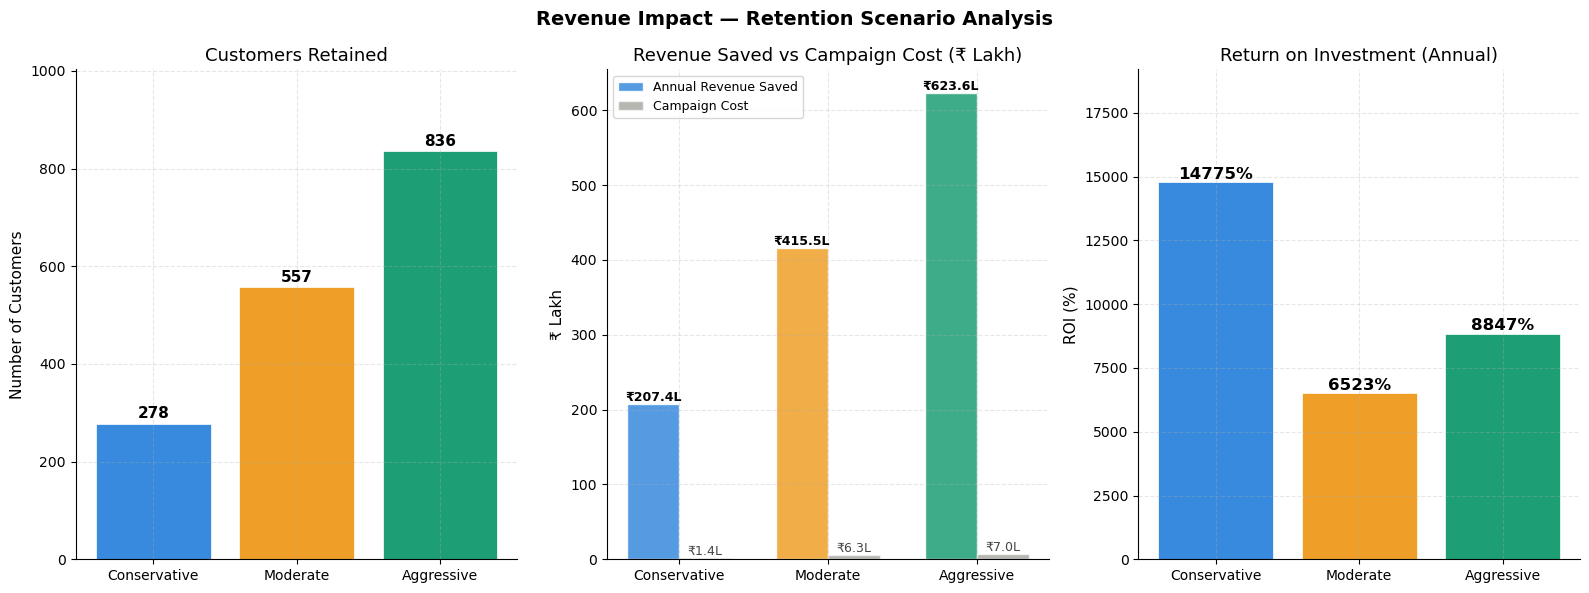

✓ Saved: fig_14_revenue_scenarios.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Revenue Impact — Retention Scenario Analysis', fontsize=14, fontweight='bold')

scenario_names = list(SCENARIOS.keys())
colors         = list(SCENARIO_COLS.values())

# Panel 1: Customers retained per scenario
ax = axes[0]
retained_counts = [scenario_df.loc[s, 'Customers Retained'] for s in scenario_names]
bars = ax.bar(scenario_names, retained_counts, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, retained_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Customers Retained')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(retained_counts) * 1.2)

# Panel 2: Revenue saved vs campaign cost
ax = axes[1]
x = np.arange(len(scenario_names))
w = 0.35
ann_saved  = [scenario_df.loc[s, 'Annual Revenue Saved (₹L)'] for s in scenario_names]
camp_costs = [scenario_df.loc[s, 'Total Campaign Cost (₹L)'] for s in scenario_names]
b1 = ax.bar(x - w/2, ann_saved,  width=w, color=colors, alpha=0.85, label='Annual Revenue Saved', edgecolor='white')
b2 = ax.bar(x + w/2, camp_costs, width=w, color='#888780', alpha=0.6, label='Campaign Cost', edgecolor='white')
for bar, val in zip(b1, ann_saved):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'₹{val:.1f}L', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(b2, camp_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'₹{val:.1f}L', ha='center', va='bottom', fontsize=9, color='#444441')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names)
ax.set_title('Revenue Saved vs Campaign Cost (₹ Lakh)')
ax.set_ylabel('₹ Lakh')
ax.legend(fontsize=9)

# Panel 3: ROI comparison
ax = axes[2]
roi_values = [scenario_df.loc[s, 'ROI (%)'] for s in scenario_names]
bars = ax.bar(scenario_names, roi_values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, roi_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Return on Investment (Annual)')
ax.set_ylabel('ROI (%)')
ax.set_ylim(0, max(roi_values) * 1.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_14_revenue_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_14_revenue_scenarios.png')

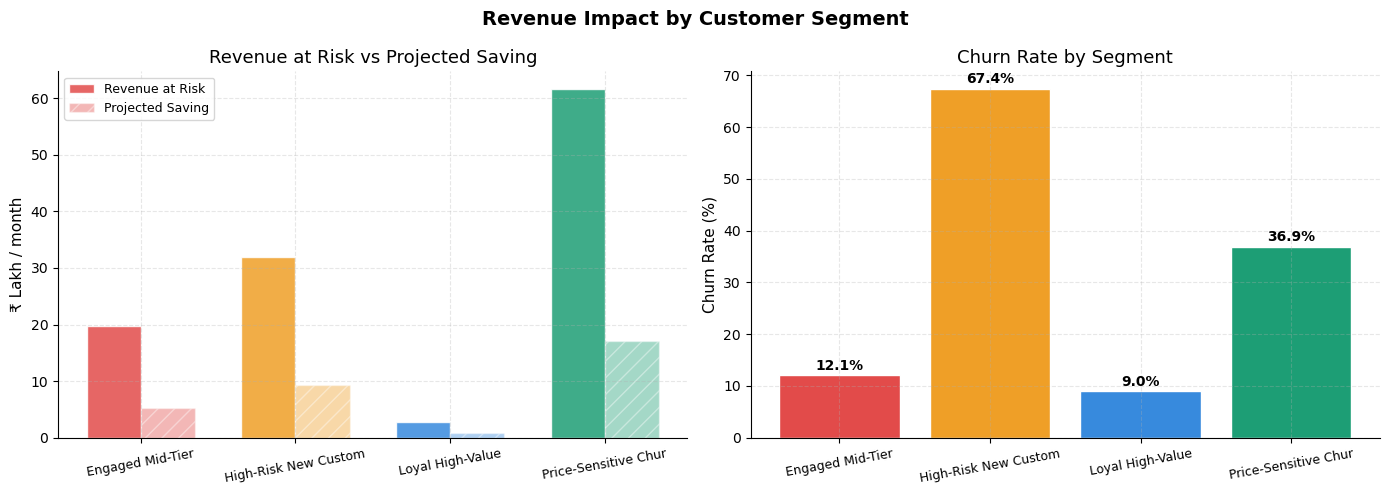

✓ Saved: fig_15_segment_revenue.png


In [20]:
# ── Segment-level revenue waterfall ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Impact by Customer Segment', fontsize=14, fontweight='bold')

seg_names = segment_impact.index.tolist()
seg_risk  = (segment_impact['monthly_rev_at_risk_inr'] / 1e5).values
seg_save  = (segment_impact['monthly_saving_moderate'] / 1e5).values
seg_colors = [COLOR_CHURN, COLOR_AMBER, COLOR_NEUTRAL, COLOR_RETAIN]

x = np.arange(len(seg_names))
w = 0.35

axes[0].bar(x - w/2, seg_risk, width=w, color=seg_colors, alpha=0.85,
            label='Revenue at Risk', edgecolor='white')
axes[0].bar(x + w/2, seg_save, width=w, color=seg_colors, alpha=0.4,
            label='Projected Saving', edgecolor='white', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels([s[:20] for s in seg_names], rotation=10, fontsize=9)
axes[0].set_ylabel('₹ Lakh / month')
axes[0].set_title('Revenue at Risk vs Projected Saving')
axes[0].legend(fontsize=9)

axes[1].bar(seg_names, segment_impact['churn_rate'].values * 100,
            color=seg_colors, edgecolor='white')
for i, (name, val) in enumerate(zip(seg_names, segment_impact['churn_rate'].values)):
    axes[1].text(i, val * 100 + 0.5, f'{val:.1%}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Segment')
axes[1].set_xticklabels([s[:20] for s in seg_names], rotation=10, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_15_segment_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_15_segment_revenue.png')

---
## 8. Export

In [21]:
scenario_df.to_csv('retention_scenarios.csv')
segment_impact.to_csv('segment_revenue_impact.csv')

print('✓ Retention scenarios saved → outputs/retention_scenarios.csv')
print('✓ Segment impact saved     → outputs/segment_revenue_impact.csv')
print('✓ Notebook 04 complete. Proceed to 05_Survival_Analysis.ipynb')

✓ Retention scenarios saved → outputs/retention_scenarios.csv
✓ Segment impact saved     → outputs/segment_revenue_impact.csv
✓ Notebook 04 complete. Proceed to 05_Survival_Analysis.ipynb
